# Lack of Robustness — Efficient Frontier Analysis

## Setup

In [15]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
import matplotlib
import pandas as pd
import numpy as np

# Rechargement fiable à chaque exécution
import importlib
import portfolio_analytics
importlib.reload(portfolio_analytics)
import portfolio_analytics as erk

## Data Loading
Industry returns from 1996 to 2000.

In [16]:
ind = erk.get_ind_returns()
er = erk.annualize_rets(ind["1996":"2000"], 12)
cov = ind["1996":"2000"].cov()

## MSR — 2-Asset Subsets
Testing the Maximum Sharpe Ratio portfolio on Food & Steel with different expected return assumptions.

In [17]:
l = ["Food", "Steel"]

# MSR with historical expected returns
print("Historical er:", er[l].values)
print("MSR weights (historical):", erk.msr(0.1, er[l], cov.loc[l, l]))

Historical er: [0.11679867 0.11580856]
MSR weights (historical): [0.75040363 0.24959637]


In [18]:
# Sensitivity: small changes in expected returns
scenarios = [
    np.array([0.11, 0.12]),
    np.array([0.10, 0.13]),
    np.array([0.13, 0.10]),
]
for s in scenarios:
    w = erk.msr(0.1, s, cov.loc[l, l])
    print(f"er={s} -> weights={w.round(3)}")

er=[0.11 0.12] -> weights=[0.579 0.421]
er=[0.1  0.13] -> weights=[0. 1.]
er=[0.13 0.1 ] -> weights=[1. 0.]


## Efficient Frontier — All Industries

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Annualized Volatility', ylabel='Annualized Return'>

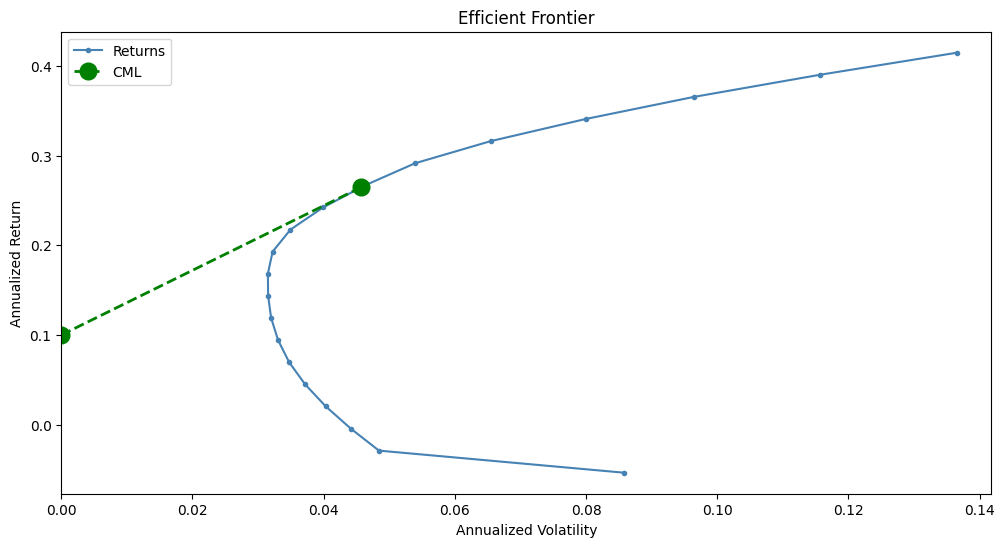

In [19]:
# Frontier with Capital Market Line
erk.plot_ef(20, er, cov, show_cml=True, riskfree_rate=0.1)

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Annualized Volatility', ylabel='Annualized Return'>

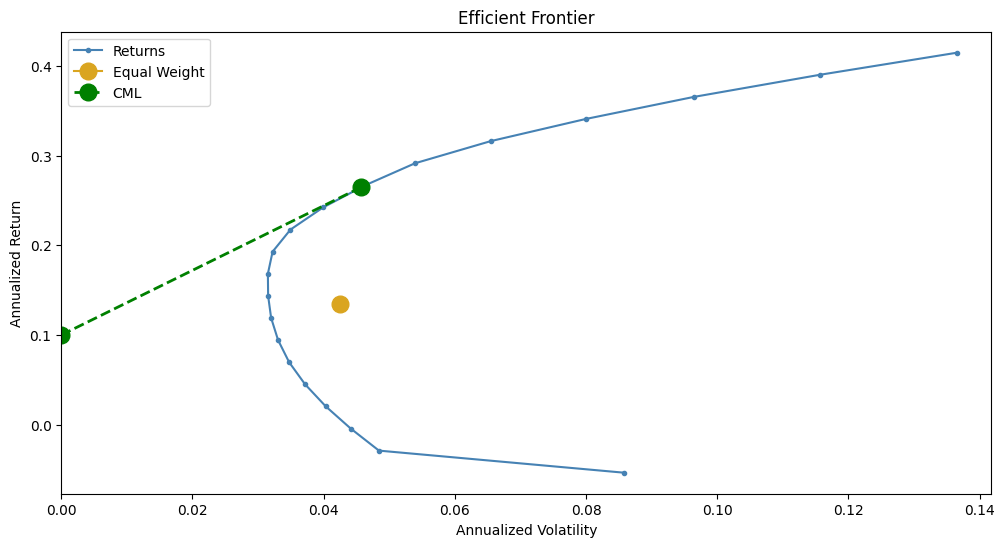

In [20]:
# Frontier with CML + Equal Weight portfolio
erk.plot_ef(20, er, cov, show_cml=True, show_ew=True, riskfree_rate=0.1)

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Annualized Volatility', ylabel='Annualized Return'>

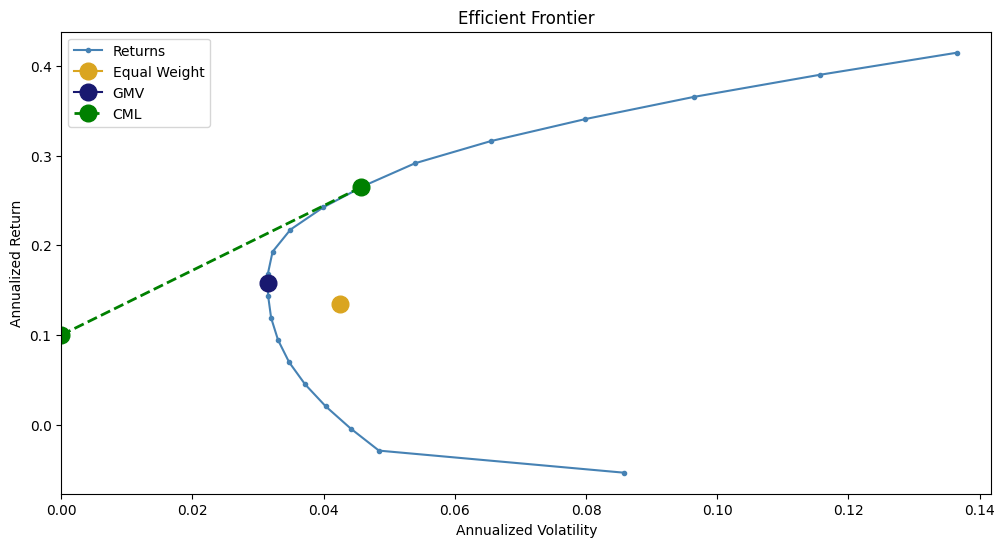

In [21]:
# Frontier with CML + Equal Weight portfolio
erk.plot_ef(20, er, cov, show_cml=True, show_ew=True, riskfree_rate=0.1, show_gmv=True)